In [1]:
import numpy as np
from matplotlib import pyplot as plt
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov_solver
from scipy.interpolate import interp1d,PchipInterpolator
import kuibit.simdir as SD
import bisect
import os
import glob
from matplotlib import pyplot as plt
from scipy.stats import linregress

In [2]:
#Physical Constants
c = 299792458  # Speed of light in m/s
G = 6.67430e-11  # Gravitational constant in m^3/kg/s^2
hc = 197.3 #hbar c Mev fm

freq_code_u_to_hz = 203000
mn = 939.56
n0 = 0.16
epsilon = mn*n0
kg_m3_to_MeV_fm3 = 5.605*10**(-16)
Pa_to_MeV_fm3 = 6.242*10**(-33)
R0 = 1.477 #Solar Mass to km conversion

geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3

geometrized_code_to_nb_n0 = (((geometrized_to_SI*(1/1476)**2)*kg_to_g/m3_to_cm3)/(1.6582*10**(-24)))*(1/(10**39))


In [3]:
eos_colors = {"BA": "red",
              "DD2F-SF1": "black",
              "DD2": "orange",
              "BHBlp": "green",
              "SFHo": "purple",
              "BLQ": "gold",
              "SLy4": "turquoise",
              "DD2F": "slategray",
              "BLh": "darkgreen",
              "LS220": "plum",
              }

core_subeos = {
              "DD2": "brown",
              "BHBlp": "green",
              "BLQ": "purple",
              "BLh": "black",
              "LS220": "red"}


In [4]:
core_db_path = '/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB'
core_db_eos_path = '/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB/EOS'
sim_names = [name for name in os.listdir(core_db_path) if os.path.isdir(os.path.join(core_db_path,name)) and (name != 'EOS' and name != 'SkyNet')]
eos_list = [name for name in os.listdir(core_db_eos_path) if os.path.isdir(os.path.join(core_db_eos_path,name))]
sim_dirs = {}

sim_info = {}

i = 0

for sim in sim_names:
    sim_info[sim] = {}
    sim_name_parsed = sim.split('_')
    eos_name = sim_name_parsed[0]
    mass_1 = float(sim_name_parsed[1])
    mass_2 = float(sim_name_parsed[2])
    mass_total = mass_1 + mass_2

    sim_info[sim]['m1'] = mass_1
    sim_info[sim]['m2'] = mass_2

    sim_info[sim]['m_total'] = mass_total
    sim_info[sim]['eos'] = eos_name

 
    
    metadata = os.path.abspath(os.path.join(core_db_path,sim,'metadata.txt'))
    with open(metadata,'r') as file:
        lines = file.readlines()
        for line in lines:
            line = line.strip('\n')
            line_split = line.split(' ')
            line_split = [x for x in line_split if x]
            if len(line_split) > 0:
                if line_split[0] == 'id_kappa2T':
                    sim_info[sim]["kappa_2T"] = float(line_split[-1])
                if line_split[0] == 'id_Lambda':
                    sim_info[sim]["Lambda_2T"] = float(line_split[-1])
                if line_split[0] == 'id_spin_starA':
                    sim_info[sim]["spin1"] = [float(line_split[-3].strip(',')),float(line_split[-2].strip(',')),float(line_split[-1].strip(','))]

    kb_sim_dirs = {}

for eos in sim_names:
    kb_sim_dirs[eos] = SD.SimDir(os.path.abspath(os.path.join(core_db_path,eos)))

    
p_cut = 600

core_db_strain = {}
core_db_gws = {}
core_db_gw_phase = {}
core_db_gw_inst_freq = {}
core_db_gw_asd = {}
core_db_gw_htilde = {}

core_fpeak = {}

for sim_name in kb_sim_dirs:
    sd = kb_sim_dirs[sim_name]
    core_db_strain[sim_name] = {}
    core_db_gws[sim_name] = {}
    for gw in sd.gws:
        extr_radius = str(gw.radius)
        core_db_gws[sim_name][extr_radius] = gw
        strain = gw.get_strain_lm(2,
                                2,
                                p_cut,
                                0.1,
                                window_function='tukey')
        core_db_strain[sim_name][extr_radius] = strain

for sim in core_db_strain:
    i = i + 1
    core_db_gw_phase[sim] = {}
    core_db_gw_inst_freq[sim] = {}
    for r in core_db_strain[sim]:
        time = core_db_strain[sim][r].t
        real_h = np.real(core_db_strain[sim][r].y)
        imag_h = np.imag(core_db_strain[sim][r].y)
        phase = np.unwrap(np.arctan2(real_h,imag_h))
        
        core_db_gw_phase[sim][r] = phase
        core_db_gw_inst_freq[sim][r] = (1/(2*np.pi))*np.gradient(phase,time)
    
    core_db_gw_asd[sim] = {}
    core_db_gw_htilde[sim] = {}
    for r in core_db_strain[sim]:
        h_plus = core_db_strain[sim][r].real()
        h_cross = core_db_strain[sim][r].imag()

        h_plus_tilde = h_plus.to_FrequencySeries()
        h_cross_tilde = h_cross.to_FrequencySeries()

        h_tilde = np.sqrt((h_plus_tilde.real()**2 + h_plus_tilde.imag()**2) + (h_cross_tilde.real()**2 + h_cross_tilde.imag()**2))
        core_db_gw_htilde[sim][r] = h_tilde
        core_db_gw_asd[sim][r] = 2.0*h_tilde.fft*np.sqrt(h_tilde.f*freq_code_u_to_hz)
    core_fpeak[sim] = core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])]*freq_code_u_to_hz/1000
    sim_info[sim]['Mfpeak'] = (core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])])*(sim_info[sim]['m_total'])
    sim_info[sim]['fpeak'] = core_fpeak[sim]
print(i)


<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0

/home/john/.local/lib/python3.10/site-packages/kuibit/timeseries.py:769: RuntimeWarning: TimeSeries is not regularly samples. Resampling.
  warnings.warn(


<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0x7aafd36bf640>
<function tukey at 0

In [5]:
eos_cs2 = {}
eos_eden = {}
eos_press = {}
eos_dens = {}
eos_mub = {}
eos_cs2p = {}
eos_dnde = {}

eos_interp = {}
dens_interp = {}
cs2p_interp = {}
eos_mub_interp = {}
eos_cs2_interp = {}
eos_cs2_dens_interp = {}
cs2p_dens_interp = {}

for eos_name in eos_list:
    if os.path.isdir(os.path.join(core_db_eos_path,eos_name)):
        pizza_files = glob.glob(os.path.join(core_db_eos_path,eos_name,'*.pizza'))
        with open(pizza_files[0]) as eos_file:
            eos_data = np.loadtxt(eos_file,skiprows=5)
            if(eos_data.shape[0] == 3): continue
            else:
                eos_dens[eos_name] = eos_data[:,0] * kg_m3_to_MeV_fm3 * (1/mn)
                eos_cs2[eos_name] = eos_data[:,3]
                eos_eden[eos_name] = (eos_data[:,1] + 1) * mn * eos_dens[eos_name]
                eos_press[eos_name] = eos_data[:,2] * Pa_to_MeV_fm3
                eos_mub[eos_name] = (eos_eden[eos_name] + eos_press[eos_name])/(eos_dens[eos_name])
    
    idx_mustart = bisect.bisect_right(eos_mub[eos_name],970)

    eos_cs2_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_cs2[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_cs2p[eos_name] = np.gradient(eos_cs2[eos_name],eos_mub[eos_name])
    eos_dnde[eos_name] = np.gradient(eos_dens[eos_name],eos_eden[eos_name])
    eos_interp[eos_name] = PchipInterpolator(eos_press[eos_name][idx_mustart:],eos_eden[eos_name][idx_mustart:])
    dens_interp[eos_name] = PchipInterpolator(eos_press[eos_name][idx_mustart:],eos_dens[eos_name][idx_mustart:])
    

    cs2p_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_cs2p[eos_name][idx_mustart:],fill_value='extrapolate')
    cs2p_dens_interp[eos_name] = interp1d(eos_dens[eos_name][idx_mustart:],eos_cs2p[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_mub_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_mub[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_cs2_dens_interp[eos_name] = interp1d(eos_dens[eos_name],eos_cs2[eos_name],fill_value='extrapolate')

def create_solver(eos_i, epsilon):
    return tov_solver(
        epsilon,
        eos = lambda p: eos_interp[eos_i](p * epsilon) / epsilon,
        bary_density= lambda p: dens_interp[eos_i](p * epsilon),
        dpde=lambda p: eos_cs2_interp[eos_i](p* epsilon)
    )

solver_list = {eos_i : create_solver(eos_i, epsilon) for eos_i in eos_interp.keys()}

In [6]:
EOS_V = rvss_eos(1200,mu_max=2700)
EOS_IV = rvss_eos(1300,mu_max=2700)
EOS_III = rvss_eos(1400,mu_max=2700)
EOS_II = rvss_eos(1500,mu_max=2700)
EOS_I = rvss_eos(1700,mu_max=2700)

solve_I = tov_solver(epsilon,lambda p: EOS_I.eos_interp(p*epsilon)/epsilon,lambda p: EOS_I.nb_interp(p*epsilon),lambda p: EOS_I.cs2_interp(p*epsilon))
solve_II = tov_solver(epsilon,lambda p: EOS_II.eos_interp(p*epsilon)/epsilon,lambda p: EOS_II.nb_interp(p*epsilon),lambda p: EOS_II.cs2_interp(p*epsilon))
solve_III = tov_solver(epsilon,lambda p: EOS_III.eos_interp(p*epsilon)/epsilon,lambda p: EOS_III.nb_interp(p*epsilon),lambda p: EOS_III.cs2_interp(p*epsilon))
solve_IV = tov_solver(epsilon,lambda p: EOS_IV.eos_interp(p*epsilon)/epsilon,lambda p: EOS_IV.nb_interp(p*epsilon),lambda p: EOS_IV.cs2_interp(p*epsilon))
solve_V = tov_solver(epsilon,lambda p: EOS_V.eos_interp(p*epsilon)/epsilon,lambda p: EOS_V.nb_interp(p*epsilon),lambda p: EOS_V.cs2_interp(p*epsilon))


RVSS_List = {"V" : [EOS_V,'red',0.0039,solve_V],  
             "IV" : [EOS_IV,'purple',0.0027,solve_IV],
             "III" : [EOS_III,'blue',0.0021,solve_III],
             "II": [EOS_II,'green',0.0017,solve_II],
             "I": [EOS_I,'black',0.0012,solve_I]}   


RVSS_f2_list_1p4 = np.asarray([2.3183139534883717, 2.935739436619718, 0.7318230115361263, 0.7441348973607038, 2.742])
RVSS_f2_list_1p3 = np.asarray([2.2601524758454103, 2.837993421052632, 3.1352294608472397, 0.71104410331384, 2.5674536256323774])
RVSS_f2_list_1p35 = np.asarray([2.640295504994450315e+00])
cs2p_1p4_list = np.asarray([RVSS_List['V'][2],RVSS_List['III'][2],RVSS_List['II'][2],RVSS_List['I'][2]])
cs2p_1p3_list = np.asarray([RVSS_List['V'][2],RVSS_List['III'][2],RVSS_List['II'][2],RVSS_List['I'][2],RVSS_List['IV'][2]])
cs2p_1p35_list = np.asanyarray([RVSS_List['IV'][2],])

RVSS_Mf2_list_1p3 = (2.6)*(RVSS_f2_list_1p3)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p4 = (2.8)*(RVSS_f2_list_1p4)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p35 = (2.7)*(RVSS_f2_list_1p35)*1000/freq_code_u_to_hz


matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [ ]:
p_cent = np.logspace(-2,1,100)
EOS_NS_Solution = {}

for eos in solver_list:
    EOS_NS_Solution[eos] = []
    print(eos)
    for pc in p_cent:
        solution = solver_list[eos].solve(pc,0.001,30,0.01)
        EOS_NS_Solution[eos].append(solution)
    

SLy4
DD2


In [8]:
p_cent = np.logspace(-2,1,100)
RVSS_NS_Solution = {}

for eos in RVSS_List:
    RVSS_NS_Solution[eos] = []
    print(eos)
    for pc in p_cent:
        solution = RVSS_List[eos][3].solve(pc,0.001,30,0.01)
        RVSS_NS_Solution[eos].append(solution)
    

V
IV
III
II
I


In [11]:
def make_psi_interpolator(eps_c_M_interp):
    def psi(eps_c):
        M = eps_c_M_interp(eps_c)
        dM = eps_c_M_interp.derivative()(eps_c)
        return 2*(eps_c / M) * dM
    return psi

In [12]:
CoRE_M = {}
CoRE_R = {}
CoRE_pc = {}
CoRE_eps_c = {}
CoRE_X = {}
CoRE_M_R_interp = {}
CoRE_M_pc_interp = {}
CoRE_Psi_Mns_interp = {}
CoRE_X_M_interp = {}
CoRE_eps_c_M_interp = {}

RVSS_M  = {}
RVSS_R  = {}
RVSS_pc = {}
RVSS_X = {}
RVSS_eps_c = {}
RVSS_M_R_interp = {}
RVSS_M_pc_interp = {}
RVSS_Psi_Mns_interp = {}
RVSS_X_M_interp = {}


for eos in RVSS_NS_Solution:
  
    RVSS_M[eos] = np.empty(100)
    RVSS_R[eos] = np.empty(100)
    RVSS_pc[eos] = np.empty(100)
    RVSS_eps_c[eos] = np.empty(100)
    RVSS_X[eos] = np.empty(100)
    for i in range(len(RVSS_NS_Solution[eos])):
        RVSS_M[eos][i] = RVSS_NS_Solution[eos][i].y[1,-1]
        RVSS_R[eos][i] = RVSS_NS_Solution[eos][i].t[-1]
        RVSS_pc[eos][i] = RVSS_NS_Solution[eos][i].y[0,0]*epsilon
        RVSS_eps_c[eos][i] = RVSS_List[eos][0].eos_interp(RVSS_pc[eos][i])
        RVSS_X[eos][i] = (RVSS_pc[eos][i])/(RVSS_eps_c[eos][i])
       
    RVSS_M_R_interp[eos] = interp1d(RVSS_M[eos],RVSS_R[eos],fill_value='interpolate')
    RVSS_M_pc_interp[eos] = interp1d(RVSS_M[eos],RVSS_pc[eos],fill_value='interpolate')
    RVSS_X_M_interp[eos] = interp1d(RVSS_M[eos],RVSS_X[eos])

    RVSS_eps_c_M_interp = PchipInterpolator(RVSS_eps_c[eos],RVSS_M[eos])
    RVSS_Psi_Mns_interp[eos] = make_psi_interpolator(RVSS_eps_c_M_interp)

for eos in EOS_NS_Solution:

    CoRE_M[eos] = np.empty(100)
    CoRE_R[eos] = np.empty(100)
    CoRE_pc[eos] = np.empty(100)
    CoRE_eps_c[eos] = np.empty(100)
    CoRE_X[eos] = np.empty(100)
    for i in range(len(EOS_NS_Solution[eos])):
        CoRE_M[eos][i] = EOS_NS_Solution[eos][i].y[1,-1]
        CoRE_R[eos][i] = EOS_NS_Solution[eos][i].t[-1]
        CoRE_pc[eos][i] = EOS_NS_Solution[eos][i].y[0,0]*epsilon
        CoRE_eps_c[eos][i] = eos_interp[eos](CoRE_pc[eos][i])
        CoRE_X[eos][i] = (CoRE_pc[eos][i]/CoRE_eps_c[eos][i])
    CoRE_M_R_interp[eos] = interp1d(CoRE_M[eos],CoRE_R[eos],fill_value='extrapolate')
    CoRE_M_pc_interp[eos] = interp1d(CoRE_M[eos],CoRE_pc[eos],fill_value='extrapolate')

    CoRE_X_M_interp[eos]= interp1d(CoRE_M[eos],CoRE_X[eos],fill_value="extrapolate")
    CoRE_eps_c_M_interp[eos] = PchipInterpolator(CoRE_eps_c[eos],CoRE_M[eos])
    CoRE_Psi_Mns_interp[eos] = make_psi_interpolator(CoRE_eps_c_M_interp[eos])
    
    
    


In [13]:
def Pi(X,Psi):
    return ((X)/(1 + 3*X**2 + 4*X))*(1 + (36*(1 + Psi)/(50 + 37*Psi + 5*Psi**2))*X)

def sc2(X,Psi):
    return X*(1 + ((1 + Psi)/(3))*((1 + 3*X**2 + 4*X)/(1 - 3*X**2)))*(1 - 24*(((1 + Psi)**2)/(4 + Psi))*((X)/(50 + 37*Psi + 5*Psi**2))) 

def Y(X,Psi):
    return 2 - (2.0/7.0)*((X)/(1 + 3*X))*((1 + 36*X + 99*X**2)/(1 + 4*X + 3*X**2) + (3)/(sc2(X,Psi)))

def H(X,Psi):
    return 13 - 11*Y(X,Psi) + 2*Pi(X,Psi)*(3*Y(X,Psi) - 2) + 8*(Pi(X,Psi)**2)*(1 + Y(X,Psi))


def H1(X,Psi):
    return 2 - Y(X,Psi) + 4*Pi(X,Psi)*(Y(X,Psi) - 1.0)

def H2(X,Psi):
    return 12*Pi(X,Psi)*(2 - Y(X,Psi) + 2*Pi(X,Psi)*(5*Y(X,Psi) - 8.0)) + 32*(Pi(X,Psi)**3)*H(X,Psi)

def xi(X,Psi):
    return 2*Pi(X,Psi)

def k2(X,Psi):
    Pi_c = Pi(X,Psi)
    Pi_c_5 = Pi_c**5
    H2_v = H2(X,Psi)
    H1_v = H1(X,Psi)
    one_minus_4Pi_c_2 = (1-4*Pi_c)**2
    # print(((H2_v)/(H1_v) + 3*((1- 4*Pi_c)**2))*np.log(1 - 4*Pi_c))
    return (256.0/5.0)*(((Pi_c_5)*one_minus_4Pi_c_2)/((H2_v)/(H1_v) + 3*one_minus_4Pi_c_2*np.log(1 - 4*Pi_c)))

In [14]:
sim_info_RVSS = {'EOS_I_1p3':{'eos': "I",'m':1.3, 'xi' : R0*(1.3)/(RVSS_M_R_interp["I"](1.3)),'xi_p':xi(RVSS_X_M_interp["I"](1.3),RVSS_Psi_Mns_interp["I"](1.3)),'k2_p': k2(RVSS_X_M_interp["I"](1.3),RVSS_Psi_Mns_interp["I"](1.3)),'Mfpeak': 0},
                 'EOS_I_1p4':{'eos': "I",'m':1.4, 'xi' : R0*(1.4)/(RVSS_M_R_interp["I"](1.4)),'xi_p':xi(RVSS_X_M_interp["I"](1.4),RVSS_Psi_Mns_interp["I"](1.4)),'k2_p': k2(RVSS_X_M_interp["I"](1.4),RVSS_Psi_Mns_interp["I"](1.4)),'Mfpeak': 0},
                 'EOS_II_1p3':{'eos': "II",'m':1.3, 'xi' : R0*(1.3)/(RVSS_M_R_interp["II"](1.3)),'xi_p':xi(RVSS_X_M_interp["II"](1.3),RVSS_Psi_Mns_interp["II"](1.3)),'k2_p': k2(RVSS_X_M_interp["II"](1.3),RVSS_Psi_Mns_interp["II"](1.3)),'Mfpeak': RVSS_Mf2_list_1p3[2]},
                 'EOS_II_1p4':{'eos': "II",'m':1.4, 'xi' : R0*(1.4)/(RVSS_M_R_interp["II"](1.4)),'xi_p':xi(RVSS_X_M_interp["II"](1.4),RVSS_Psi_Mns_interp["II"](1.4)),'k2_p': k2(RVSS_X_M_interp["II"](1.4),RVSS_Psi_Mns_interp["II"](1.4)),'Mfpeak': 0},
                 'EOS_III_1p3':{'eos': "III",'m':1.3, 'xi' : R0*(1.3)/(RVSS_M_R_interp["III"](1.3)),'xi_p':xi(RVSS_X_M_interp["III"](1.3),RVSS_Psi_Mns_interp["III"](1.3)),'k2_p': k2(RVSS_X_M_interp["III"](1.3),RVSS_Psi_Mns_interp["III"](1.3)),'Mfpeak': RVSS_Mf2_list_1p3[1]},
                 'EOS_III_1p4':{'eos': "III",'m':1.4,'xi' : R0*(1.4)/(RVSS_M_R_interp["III"](1.4)),'xi_p':xi(RVSS_X_M_interp["III"](1.4),RVSS_Psi_Mns_interp["III"](1.4)),'k2_p': k2(RVSS_X_M_interp["III"](1.4),RVSS_Psi_Mns_interp["III"](1.4)),'Mfpeak' : RVSS_Mf2_list_1p4[1]},
                 'EOS_IV_1p3':{'eos': "IV",'m':1.3,'xi' : R0*(1.3)/(RVSS_M_R_interp["IV"](1.3)),'xi_p':xi(RVSS_X_M_interp["IV"](1.3),RVSS_Psi_Mns_interp["IV"](1.3)),'k2_p': k2(RVSS_X_M_interp["IV"](1.3),RVSS_Psi_Mns_interp["IV"](1.3)),'Mfpeak': RVSS_Mf2_list_1p3[4]},
                 'EOS_IV_1p35':{'eos': "IV",'m':1.35,'xi' : R0*(1.35)/(RVSS_M_R_interp["IV"](1.35)),'xi_p':xi(RVSS_X_M_interp["IV"](1.35),RVSS_Psi_Mns_interp["IV"](1.35)),'k2_p': k2(RVSS_X_M_interp["IV"](1.35),RVSS_Psi_Mns_interp["IV"](1.35)),'Mfpeak': RVSS_Mf2_list_1p35[0]},
                 'EOS_IV_1p4' :{'eos' : "IV", 'm': 1.4,'xi' : R0*(1.4)/(RVSS_M_R_interp["IV"](1.4)),'xi_p':xi(RVSS_X_M_interp["IV"](1.4),RVSS_Psi_Mns_interp["IV"](1.4)),'k2_p': k2(RVSS_X_M_interp["IV"](1.4),RVSS_Psi_Mns_interp["IV"](1.4)),'Mfpeak' : RVSS_Mf2_list_1p4[4]},
                 'EOS_V_1p3':{'eos': "V",'m':1.3,'xi' : R0*(1.3)/(RVSS_M_R_interp["V"](1.3)),'xi_p':xi(RVSS_X_M_interp["V"](1.3),RVSS_Psi_Mns_interp["V"](1.3)),'k2_p': k2(RVSS_X_M_interp["V"](1.3),RVSS_Psi_Mns_interp["V"](1.3)),'Mfpeak' : RVSS_Mf2_list_1p3[0]},
                 'EOS_V_1p4':{'eos': "V",'m':1.4,'xi' : R0*(1.4)/(RVSS_M_R_interp["V"](1.4)),'xi_p':xi(RVSS_X_M_interp["V"](1.4),RVSS_Psi_Mns_interp["V"](1.4)),'k2_p': k2(RVSS_X_M_interp["V"](1.3),RVSS_Psi_Mns_interp["V"](1.4)),'Mfpeak' : RVSS_Mf2_list_1p4[0]}}

In [100]:
sim_info_core_subeos = {}

i = 0
for sim in sim_info:
    if sim_info[sim]['eos'] in core_subeos  and sim_info[sim]['Mfpeak'] > 0.025:
        #print(i)
        print(sim_info[sim]['spin1'])
        m1 = sim_info[sim]['m1']
        m2 = sim_info[sim]['m2']
        sim_info_core_subeos[sim] = sim_info[sim]
        p_central_1 = CoRE_M_pc_interp[sim_info_core_subeos[sim]['eos']](m1)
        p_central_2 = CoRE_M_pc_interp[sim_info_core_subeos[sim]['eos']](m2)

        eps_central_1 = eos_interp[sim_info_core_subeos[sim]['eos']](p_central_1)
        eps_central_2 = eos_interp[sim_info_core_subeos[sim]['eos']](p_central_2)

        Psi_c_1 = CoRE_Psi_Mns_interp[eos](eps_central_1)
        Psi_c_2 = CoRE_Psi_Mns_interp[eos](eps_central_2)

        X_1 = CoRE_X_M_interp[sim_info_core_subeos[sim]['eos']](m1)
        X_2 = CoRE_X_M_interp[sim_info_core_subeos[sim]['eos']](m2)

        xi_1 = xi(X_1,Psi_c_1)
        xi_2 = xi(X_2,Psi_c_2)

        k2_1 = k2(X_1,Psi_c_1)
        k2_2 = k2(X_2,Psi_c_2)

        D_1 = (2.0/3.0)*(k2_1/(xi_1**5))
        D_2 = (2.0/3.0)*(k2_2/(xi_2**5))

        D_avg = (D_1 + D_2)/2
        D_tilde = (16.0/13.0)*((m1 + 12*m2)*(m1**4)*D_1 + (m2 + 12*m1)*(m2**4)*D_2)/((m1 + m2)**5)

        sim_info_core_subeos[sim]['xi_1'] = xi_1
        sim_info_core_subeos[sim]['xi_2'] = xi_2
        
        sim_info_core_subeos[sim]['k2_1'] = k2_1
        sim_info_core_subeos[sim]['k2_2'] = k2_2
        sim_info_core_subeos[sim]['D_1'] = D_1
        sim_info_core_subeos[sim]['D_2'] = D_2
        sim_info_core_subeos[sim]['D_avg'] = D_avg
        sim_info_core_subeos[sim]['D_tilde'] = D_tilde
        i = i + 1



[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.

In [93]:
i = 0 
for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['Mfpeak'] > 0.025:

        p_central = RVSS_M_pc_interp[sim_info_RVSS[sim]['eos']](sim_info_RVSS[sim]['m'])
        eps_central = RVSS_List[sim_info_RVSS[sim]['eos']][0].eos_interp(p_central)

        X = RVSS_X_M_interp[sim_info_RVSS[sim]['eos']](sim_info_RVSS[sim]['m'])
        Psi_C = RVSS_Psi_Mns_interp[sim_info_RVSS[sim]['eos']](sim_info_RVSS[sim]['m'])
        sim_info_RVSS[sim]['xi_p'] = xi(X,Psi_C)
        sim_info_RVSS[sim]['k2_p'] = k2(X,Psi_C)

        sim_info_RVSS[sim]['D'] = (2.0/3.0)*(sim_info_RVSS[sim]['k2_p']/(sim_info_RVSS[sim]['xi_p']**5))
        print(sim_info_RVSS[sim]['D'])
        i = i + 1

124.04627566602412
148.9773903741201
96.898527656709
175.51127062175772
143.69731043517558
118.28369535756647
204.7460941199621
142.22873232748626


In [ ]:
D_for_lin_regress = []
Mf2_for_lin_regress = []

D_for_lin_regress_q1 = []
Mf2_for_lin_regress_q1 = []

for sim in sim_info_core_subeos:

    D_for_lin_regress.append(sim_info_core_subeos[sim]['D_tilde'])
    Mf2_for_lin_regress.append(sim_info_core_subeos[sim]['Mfpeak'])
    if sim_info_core_subeos[sim]['m1'] == sim_info_core_subeos[sim]['m2']:
        D_for_lin_regress_q1.append(sim_info_core_subeos[sim]['D_tilde'])
        Mf2_for_lin_regress_q1.append(sim_info_core_subeos[sim]['Mfpeak'])

for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['Mfpeak'] > 0.020:
        D_for_lin_regress.append(sim_info_RVSS[sim]['D'])
        Mf2_for_lin_regress.append(sim_info_RVSS[sim]['Mfpeak'])
        D_for_lin_regress_q1.append(sim_info_RVSS[sim]['D'])
        Mf2_for_lin_regress_q1.append(sim_info_RVSS[sim]['Mfpeak'])

D_for_lin_regress = np.asarray(D_for_lin_regress)
Mf2_for_lin_regress = np.asarray(Mf2_for_lin_regress)
D_for_lin_regress_q1 = np.asarray(D_for_lin_regress_q1)
Mf2_for_lin_regress_q1 = np.asarray(Mf2_for_lin_regress_q1)

D_tot_lin_regress = np.concatenate([D_for_lin_regress,D_for_lin_regress_q1])
Mf2_tot_lin_regress = np.concatenate([Mf2_for_lin_regress,Mf2_for_lin_regress_q1])

In [104]:
D_mf2_linregress = linregress(D_for_lin_regress,Mf2_for_lin_regress)
D_mf2_linregress_q1 = linregress(D_for_lin_regress_q1,Mf2_for_lin_regress_q1)

D_mf2_linregress_tot = linregress(D_tot_lin_regress,Mf2_tot_lin_regress)


print(f'R^2 (q != 1): {D_mf2_linregress.rvalue**2}')
print(f'R^2 (q=1) : {D_mf2_linregress_q1.rvalue**2}')
print(f'R^2 total : {D_mf2_linregress_tot.rvalue**2}')

R^2 (q != 1): 0.6625404866850898
R^2 (q=1) : 0.7512579511100946
R^2 total : 0.6925740702655975


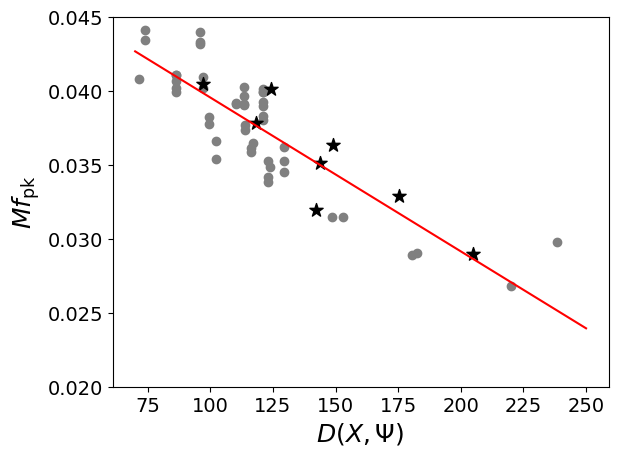

In [96]:
axes_label_fontsize = 18
tick_label_fontsize = 14
text_fontsize = 22
point_size = 90

Mf2_scale_fig,Mf2_scale_ax = plt.subplots(1)

D_grid = np.linspace(70,250,150)
fit_data = D_mf2_linregress_q1.slope*D_grid + D_mf2_linregress_q1.intercept
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['m1'] == sim_info_core_subeos[sim]['m2']:
        Mf2_scale_ax.scatter(sim_info_core_subeos[sim]['D'],sim_info_core_subeos[sim]['Mfpeak'],color='Grey')

for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['Mfpeak'] > 0.02:
        Mf2_scale_ax.scatter(sim_info_RVSS[sim]['D'],sim_info_RVSS[sim]['Mfpeak'],marker='*',s=100,color='Black')

Mf2_scale_ax.plot(D_grid,fit_data,color='red')
Mf2_scale_ax.set_ylim([0.020,0.045])
Mf2_scale_ax.set_xlabel(r"$D\left(X,\Psi\right)$",fontsize=axes_label_fontsize)
Mf2_scale_ax.set_ylabel(r"$Mf_{\text{pk}}$",fontsize=axes_label_fontsize)
Mf2_scale_ax.tick_params(labelsize=tick_label_fontsize)



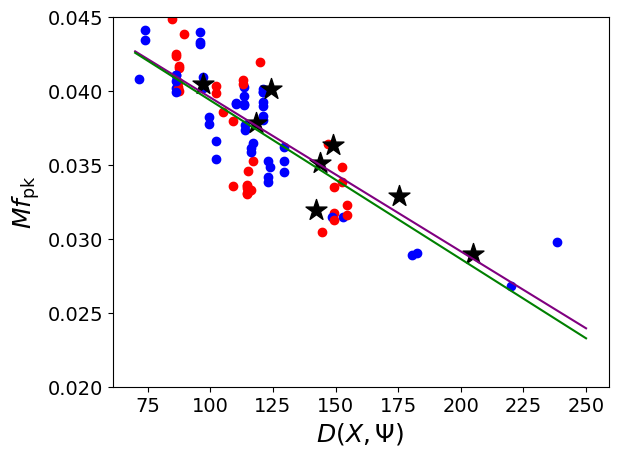

In [106]:
axes_label_fontsize = 18
tick_label_fontsize = 14
text_fontsize = 22
point_size = 250

Mf2_scale_fig,Mf2_scale_ax = plt.subplots(1)

D_grid = np.linspace(70,250,150)
fit_data_q1 = D_mf2_linregress_q1.slope*D_grid + D_mf2_linregress_q1.intercept
fit_data_tot = D_mf2_linregress_tot.slope*D_grid + D_mf2_linregress_tot.intercept
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['m1'] == sim_info_core_subeos[sim]['m2']:
        Mf2_scale_ax.scatter(sim_info_core_subeos[sim]['D'],sim_info_core_subeos[sim]['Mfpeak'],color='blue')
    elif sim_info_core_subeos[sim]['spin1'] != [0,0,0]:
        Mf2_scale_ax.scatter(sim_info_core_subeos[sim]['D_tilde'],sim_info_core_subeos[sim]['Mfpeak'],color='green')
    else:
        Mf2_scale_ax.scatter(sim_info_core_subeos[sim]['D_tilde'],sim_info_core_subeos[sim]['Mfpeak'],color='red')


for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['Mfpeak'] > 0.02:
        Mf2_scale_ax.scatter(sim_info_RVSS[sim]['D'],sim_info_RVSS[sim]['Mfpeak'],marker='*',s=point_size,color='Black')

Mf2_scale_ax.plot(D_grid,fit_data,color='purple')
Mf2_scale_ax.plot(D_grid,fit_data_tot,color='green')
Mf2_scale_ax.set_ylim([0.020,0.045])
Mf2_scale_ax.set_xlabel(r"$D\left(X,\Psi\right)$",fontsize=axes_label_fontsize)
Mf2_scale_ax.set_ylabel(r"$Mf_{\text{pk}}$",fontsize=axes_label_fontsize)
Mf2_scale_ax.tick_params(labelsize=tick_label_fontsize)

